# 1. Data Overview

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('credit_risk_dataset.csv')

display(df.head())
print(df.shape)

# 2. Data Preprocessing and Cleaning

In [15]:
df = df.drop_duplicates()

df = df[(df['person_age'] <= 100) & (df['person_age'] >= 0)]
df = df[(df['person_emp_length'] <= 70) & (df['person_emp_length'] >= 0)]
df = df[(df['loan_percent_income']<=1) & (df['loan_percent_income']>=0)]
df = df[(df['loan_int_rate']<=100) & (df['loan_int_rate']>=0)]
df = df[(df['person_home_ownership']=='RENT') | (df['person_home_ownership']=='OWN') | (df['person_home_ownership']=='MORTGAGE')]
df = df[(df['cb_person_default_on_file']=='Y') | (df['cb_person_default_on_file']=='N')]


df = df.dropna()

print(df.shape)

(28402, 12)


# 3. Exploratory Data Analysis

In [16]:
sns.set_theme(style="whitegrid")

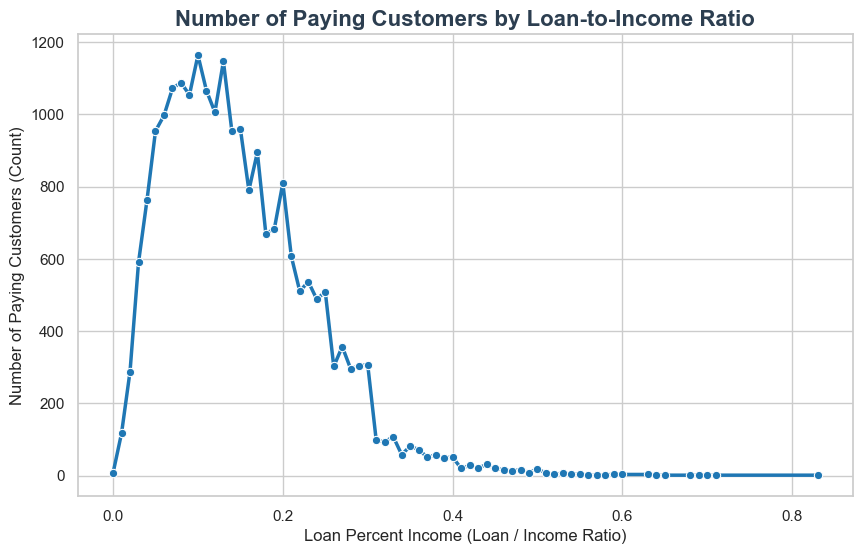

In [17]:
plt.figure(figsize=(10, 6))

df_paid = df[df['loan_status'] == 0].copy()
df_paid['loan_percent_rounded'] = df_paid['loan_percent_income'].round(2)
line_data = df_paid.groupby('loan_percent_rounded').size().reset_index(name='customer_count')
sns.lineplot(data=line_data, x='loan_percent_rounded', y='customer_count', color='#1f77b4', linewidth=2.5, marker='o')
plt.title('Number of Paying Customers by Loan-to-Income Ratio', fontsize=16, fontweight='bold', color='#2c3e50')
plt.xlabel('Loan Percent Income (Loan / Income Ratio)', fontsize=12)
plt.ylabel('Number of Paying Customers (Count)', fontsize=12)
plt.show()

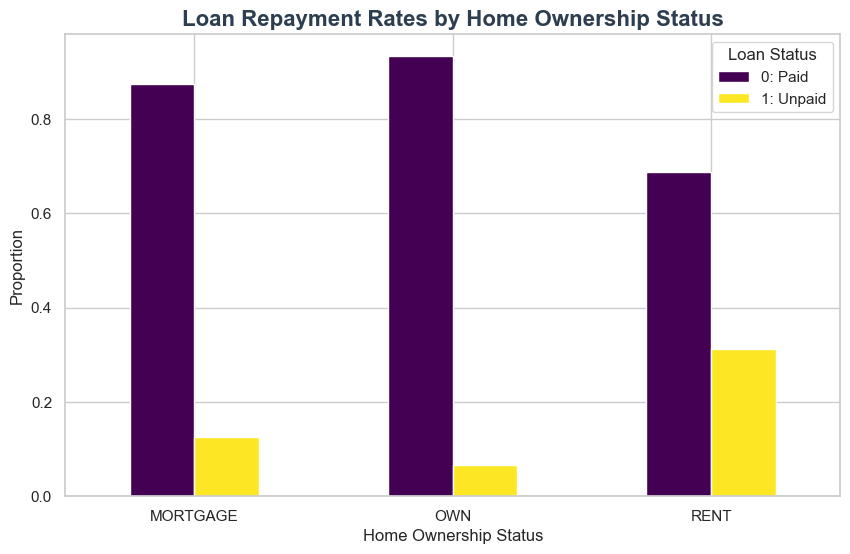

In [18]:
home_ownership_crosstab = pd.crosstab(df['person_home_ownership'], df['loan_status'], normalize='index')
home_ownership_crosstab.plot(kind='bar', stacked=False, figsize=(10, 6), colormap='viridis')
plt.title('Loan Repayment Rates by Home Ownership Status', fontsize=16, fontweight='bold', color='#2c3e50')
plt.xlabel('Home Ownership Status', fontsize=12)
plt.ylabel('Proportion', fontsize=12)
plt.legend(title='Loan Status', labels=['0: Paid', '1: Unpaid'], loc='upper right')
plt.xticks(rotation=0)
plt.show()

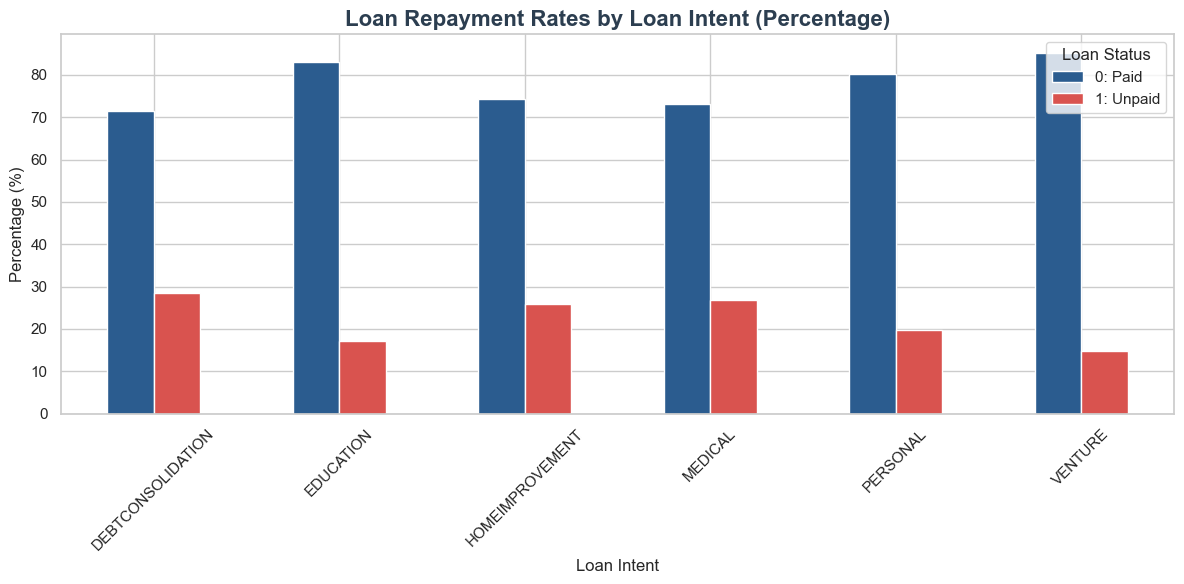

In [19]:
loan_intent_crosstab = pd.crosstab(df['loan_intent'], df['loan_status'], normalize='index')
loan_intent_crosstab_pct = loan_intent_crosstab * 100
loan_intent_crosstab_pct.plot(kind='bar', stacked=False, figsize=(12, 6), color=['#2b5c8f', '#d9534f'])
plt.title('Loan Repayment Rates by Loan Intent (Percentage)', fontsize=16, fontweight='bold', color='#2c3e50')
plt.xlabel('Loan Intent', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(title='Loan Status', labels=['0: Paid', '1: Unpaid'], loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

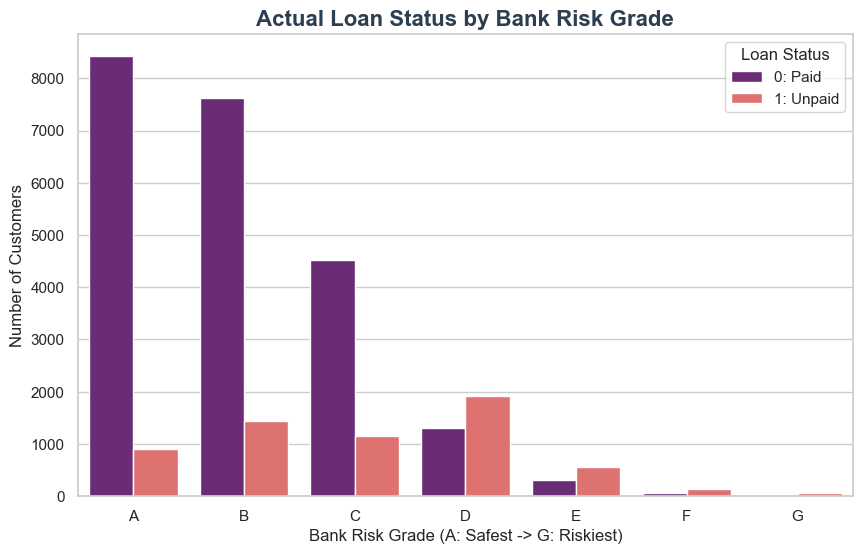

In [20]:
plt.figure(figsize=(10, 6))
sns.countplot(x='loan_grade', hue='loan_status', data=df, palette='magma', order=['A', 'B', 'C', 'D', 'E', 'F', 'G'])
plt.title('Actual Loan Status by Bank Risk Grade', fontsize=16, fontweight='bold', color='#2c3e50')
plt.xlabel('Bank Risk Grade (A: Safest -> G: Riskiest)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.legend(title='Loan Status', labels=['0: Paid', '1: Unpaid'])
plt.show()

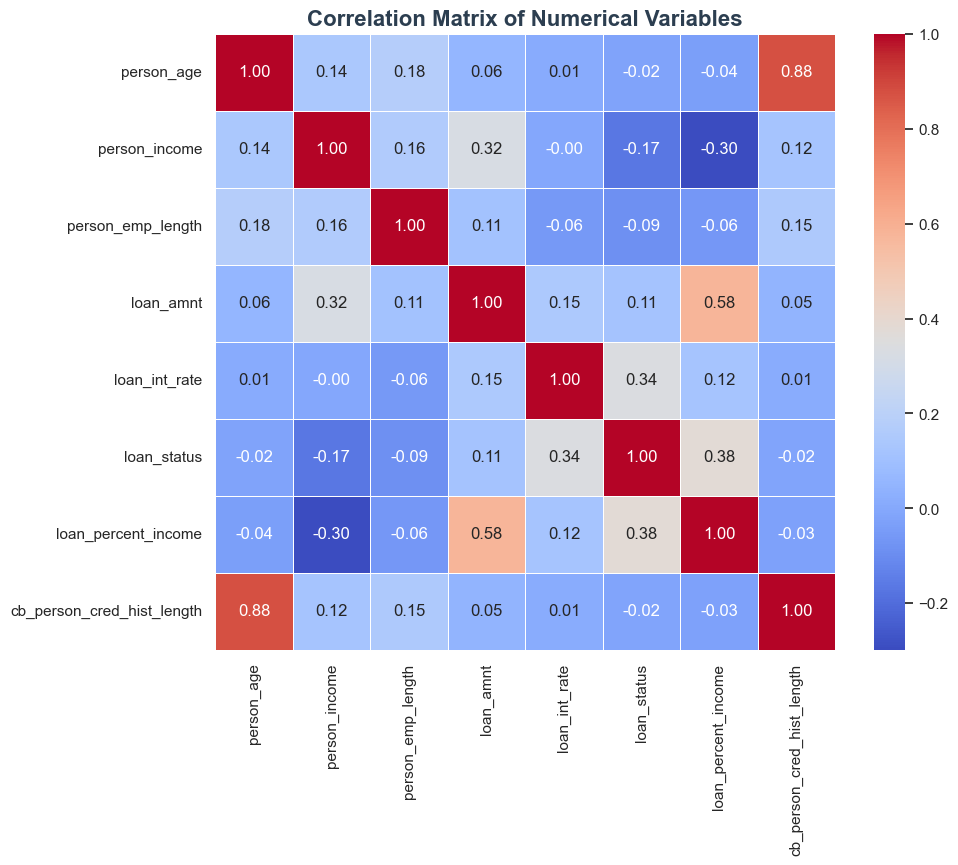

In [21]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables', fontsize=16, fontweight='bold', color='#2c3e50')
plt.show()

# 4. Machine Learning

### Feature Engineering & Encoding

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

X = df.drop('loan_status', axis=1)
y = df['loan_status']
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Logistic Regression

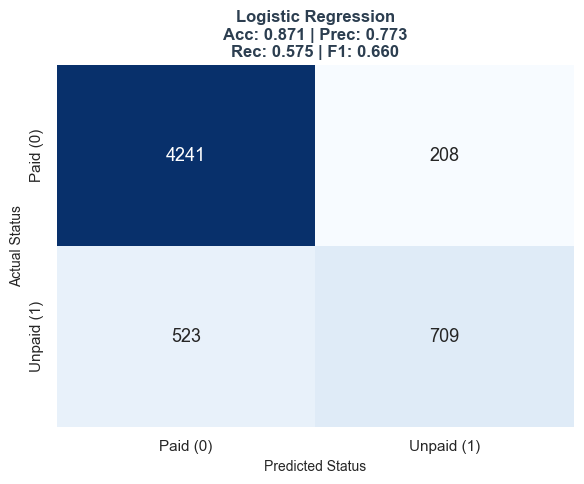

In [23]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

cm_lr = confusion_matrix(y_test, lr_preds)
acc_lr = accuracy_score(y_test, lr_preds)
prec_lr = precision_score(y_test, lr_preds)
rec_lr = recall_score(y_test, lr_preds)
f1_lr = f1_score(y_test, lr_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Paid (0)', 'Unpaid (1)'], yticklabels=['Paid (0)', 'Unpaid (1)'], annot_kws={"size": 13})

title_lr = f"Logistic Regression\nAcc: {acc_lr:.3f} | Prec: {prec_lr:.3f}\nRec: {rec_lr:.3f} | F1: {f1_lr:.3f}"
plt.title(title_lr, fontsize=12, fontweight='bold', color='#2c3e50')
plt.ylabel('Actual Status', fontsize=10)
plt.xlabel('Predicted Status', fontsize=10)
plt.tight_layout()
plt.show()

### KNN

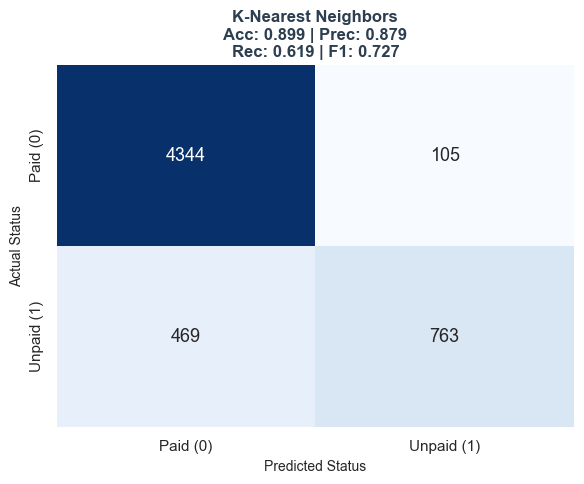

In [24]:
knn_model = KNeighborsClassifier(n_neighbors=11)
knn_model.fit(X_train_scaled, y_train)
knn_preds = knn_model.predict(X_test_scaled)

cm_knn = confusion_matrix(y_test, knn_preds)
acc_knn = accuracy_score(y_test, knn_preds)
prec_knn = precision_score(y_test, knn_preds)
rec_knn = recall_score(y_test, knn_preds)
f1_knn = f1_score(y_test, knn_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Paid (0)', 'Unpaid (1)'], yticklabels=['Paid (0)', 'Unpaid (1)'], annot_kws={"size": 13})

title_knn = f"K-Nearest Neighbors\nAcc: {acc_knn:.3f} | Prec: {prec_knn:.3f}\nRec: {rec_knn:.3f} | F1: {f1_knn:.3f}"
plt.title(title_knn, fontsize=12, fontweight='bold', color='#2c3e50')
plt.ylabel('Actual Status', fontsize=10)
plt.xlabel('Predicted Status', fontsize=10)
plt.tight_layout()
plt.show()

### Decision Tree

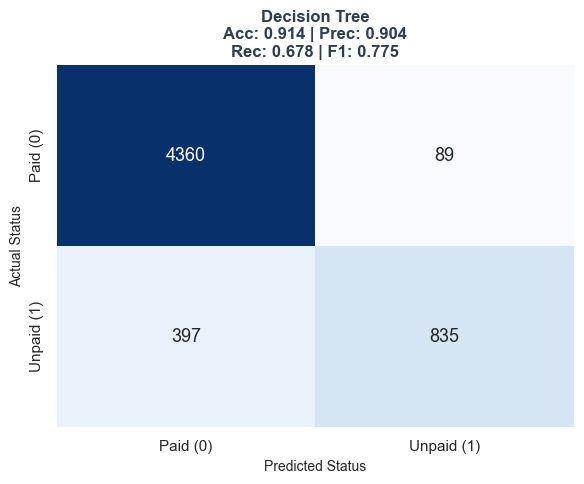

In [25]:
dt_model = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_model.fit(X_train_scaled, y_train)
dt_preds = dt_model.predict(X_test_scaled)

cm_dt = confusion_matrix(y_test, dt_preds)
acc_dt = accuracy_score(y_test, dt_preds)
prec_dt = precision_score(y_test, dt_preds)
rec_dt = recall_score(y_test, dt_preds)
f1_dt = f1_score(y_test, dt_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Paid (0)', 'Unpaid (1)'], yticklabels=['Paid (0)', 'Unpaid (1)'], annot_kws={"size": 13})

title_dt = f"Decision Tree\nAcc: {acc_dt:.3f} | Prec: {prec_dt:.3f}\nRec: {rec_dt:.3f} | F1: {f1_dt:.3f}"
plt.title(title_dt, fontsize=12, fontweight='bold', color='#2c3e50')
plt.ylabel('Actual Status', fontsize=10)
plt.xlabel('Predicted Status', fontsize=10)
plt.tight_layout()
plt.show()

### Random Forest

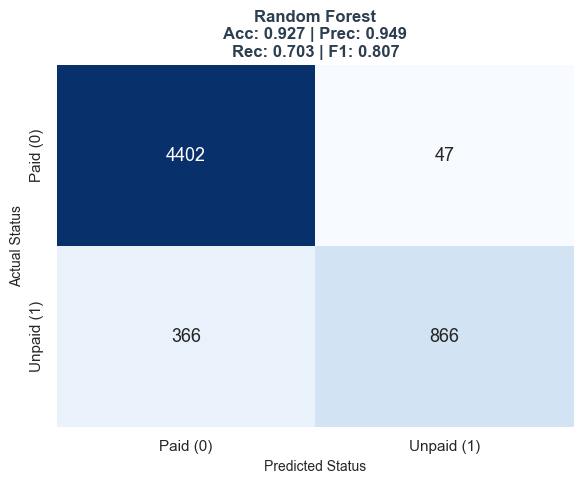

In [26]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)

cm_rf = confusion_matrix(y_test, rf_preds)
acc_rf = accuracy_score(y_test, rf_preds)
prec_rf = precision_score(y_test, rf_preds)
rec_rf = recall_score(y_test, rf_preds)
f1_rf = f1_score(y_test, rf_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Paid (0)', 'Unpaid (1)'], yticklabels=['Paid (0)', 'Unpaid (1)'], annot_kws={"size": 13})

title_rf = f"Random Forest\nAcc: {acc_rf:.3f} | Prec: {prec_rf:.3f}\nRec: {rec_rf:.3f} | F1: {f1_rf:.3f}"
plt.title(title_rf, fontsize=12, fontweight='bold', color='#2c3e50')
plt.ylabel('Actual Status', fontsize=10)
plt.xlabel('Predicted Status', fontsize=10)
plt.tight_layout()
plt.show()